<a href="https://colab.research.google.com/github/annkupina/ml_course_hw/blob/main/Anna_Kupina_HW_2_3_%D0%94%D0%B5%D1%80%D0%B5%D0%B2%D0%B0_%D0%BF%D1%80%D0%B8%D0%B9%D0%BD%D1%8F%D1%82%D1%82%D1%8F_%D1%80%D1%96%D1%88%D0%B5%D0%BD%D1%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



https://github.com/annkupina/ml_course_hw/blob/main/process_bank_churn.py

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

In [5]:
raw_df = pd.read_csv('train.csv')

In [6]:
from process_bank_churn import preprocess_data

In [26]:
X_train, y_train, X_val, y_val, input_cols, scaler, encoder = preprocess_data(raw_df, scaler_numeric = False)

**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

In [27]:
from sklearn.tree import DecisionTreeClassifier

In [28]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [31]:
from sklearn.metrics import roc_auc_score

def evaluate_auc(X_train, y_train, X_val, y_val):
  train_probs = model.predict_proba(X_train)[:, 1]
  val_probs = model.predict_proba(X_val)[:, 1]

  train_auc = roc_auc_score(y_train, train_probs)
  val_auc = roc_auc_score(y_val, val_probs)

  print(f'Train AUC: {train_auc:.4f}')
  print(f'Validation AUC: {val_auc:.4f}')

In [32]:
evaluate_auc(X_train, y_train, X_val, y_val)

Train AUC: 1.0000
Validation AUC: 0.7643


Модель перетренована, на тренувальних даних показує відмінну якість, а на валідаційних суттєво гіршу.

In [33]:
model.tree_.max_depth

31

In [34]:
model = DecisionTreeClassifier(max_depth=2, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [35]:
evaluate_auc(X_train, y_train, X_val, y_val)

Train AUC: 0.8497
Validation AUC: 0.8442


In [36]:
from sklearn.tree import plot_tree, export_text
tree_text = export_text(model, max_depth=2, feature_names=list(X_train.columns))
print(tree_text[:5000])

|--- Age <= 42.50
|   |--- NumOfProducts <= 1.50
|   |   |--- class: 0.0
|   |--- NumOfProducts >  1.50
|   |   |--- class: 0.0
|--- Age >  42.50
|   |--- NumOfProducts <= 1.50
|   |   |--- class: 1.0
|   |--- NumOfProducts >  1.50
|   |   |--- class: 0.0



Найвпливовішими є ознаки Age та NumOfProducts.

In [38]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

importance_df.head(10)

,feature,importance
1,Age,0.685631
4,NumOfProducts,0.314369
0,CreditScore,0.000000
2,Tenure,0.000000
3,Balance,0.000000
5,HasCrCard,0.000000
6,IsActiveMember,0.000000
7,EstimatedSalary,0.000000
8,Geography_France,0.000000
9,Geography_Germany,0.000000


**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

In [76]:
model = DecisionTreeClassifier(max_leaf_nodes=31, random_state=42)
model.fit(X_train, y_train)
evaluate_auc(X_train, y_train, X_val, y_val)

Train AUC: 0.9247
Validation AUC: 0.9123


In [71]:
model = DecisionTreeClassifier(max_depth=6, random_state=42)
model.fit(X_train, y_train)
evaluate_auc(X_train, y_train, X_val, y_val)

Train AUC: 0.9344
Validation AUC: 0.9142


**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

In [83]:
train_aucs = []
val_aucs = []
max_depths = range(1, 21)

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    train_probs = model.predict_proba(X_train)[:, 1]
    val_probs = model.predict_proba(X_val)[:, 1]

    train_auc = roc_auc_score(y_train, train_probs)
    val_auc = roc_auc_score(y_val, val_probs)

    train_aucs.append(train_auc)
    val_aucs.append(val_auc)

    print(f'max_depth={depth:2d} | Train AUC: {train_auc:.4f} | Validation AUC: {val_auc:.4f}')

max_depth= 1 | Train AUC: 0.7570 | Validation AUC: 0.7533
max_depth= 2 | Train AUC: 0.8497 | Validation AUC: 0.8442
max_depth= 3 | Train AUC: 0.8964 | Validation AUC: 0.8910
max_depth= 4 | Train AUC: 0.9116 | Validation AUC: 0.9001
max_depth= 5 | Train AUC: 0.9263 | Validation AUC: 0.9107
max_depth= 6 | Train AUC: 0.9344 | Validation AUC: 0.9142
max_depth= 7 | Train AUC: 0.9415 | Validation AUC: 0.9039
max_depth= 8 | Train AUC: 0.9500 | Validation AUC: 0.8982
max_depth= 9 | Train AUC: 0.9594 | Validation AUC: 0.8869
max_depth=10 | Train AUC: 0.9698 | Validation AUC: 0.8617
max_depth=11 | Train AUC: 0.9792 | Validation AUC: 0.8376
max_depth=12 | Train AUC: 0.9878 | Validation AUC: 0.8181
max_depth=13 | Train AUC: 0.9934 | Validation AUC: 0.7990
max_depth=14 | Train AUC: 0.9966 | Validation AUC: 0.7822
max_depth=15 | Train AUC: 0.9984 | Validation AUC: 0.7824
max_depth=16 | Train AUC: 0.9992 | Validation AUC: 0.7857
max_depth=17 | Train AUC: 0.9996 | Validation AUC: 0.7747
max_depth=18 |

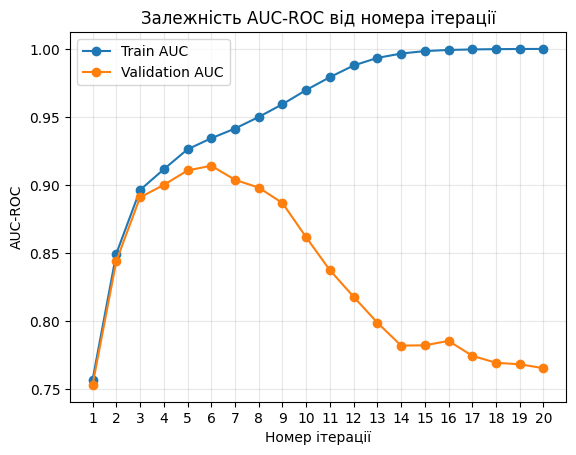

In [86]:
import matplotlib.pyplot as plt

iterations = list(range(1, len(max_depths) + 1))

plt.plot(iterations, train_aucs, marker='o', label='Train AUC')
plt.plot(iterations, val_aucs, marker='o', label='Validation AUC')
plt.xlabel('Номер ітерації')
plt.ylabel('AUC-ROC')
plt.title('Залежність AUC-ROC від номера ітерації')
plt.legend()
plt.xticks(iterations)
plt.grid(True, alpha=0.3)
plt.show()

**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [88]:
model = DecisionTreeClassifier(max_depth=6, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, random_state=42)

In [89]:
test_raw_df = pd.read_csv('test.csv')

In [94]:
from process_bank_churn import preprocess_new_data

X_test = preprocess_new_data(test_raw_df, input_cols=input_cols, scaler=scaler, encoder=encoder)

In [97]:
X_test.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,584.0,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.0,1.0,0.0,0.0,1.0
1,551.0,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,1.0,0.0,0.0,0.0,1.0
2,706.0,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,1.0,0.0,0.0,0.0,1.0
3,717.0,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.0,0.0,1.0,0.0,1.0
4,592.0,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.0,0.0,1.0,0.0,1.0


In [107]:
test_proba = model.predict_proba(X_test)

In [113]:
sample_submission = pd.read_csv('sample_submission.csv')

sample_submission['Exited'] = test_proba[:, 1]

sample_submission.to_csv('submission_decision_trees.csv', index=False)

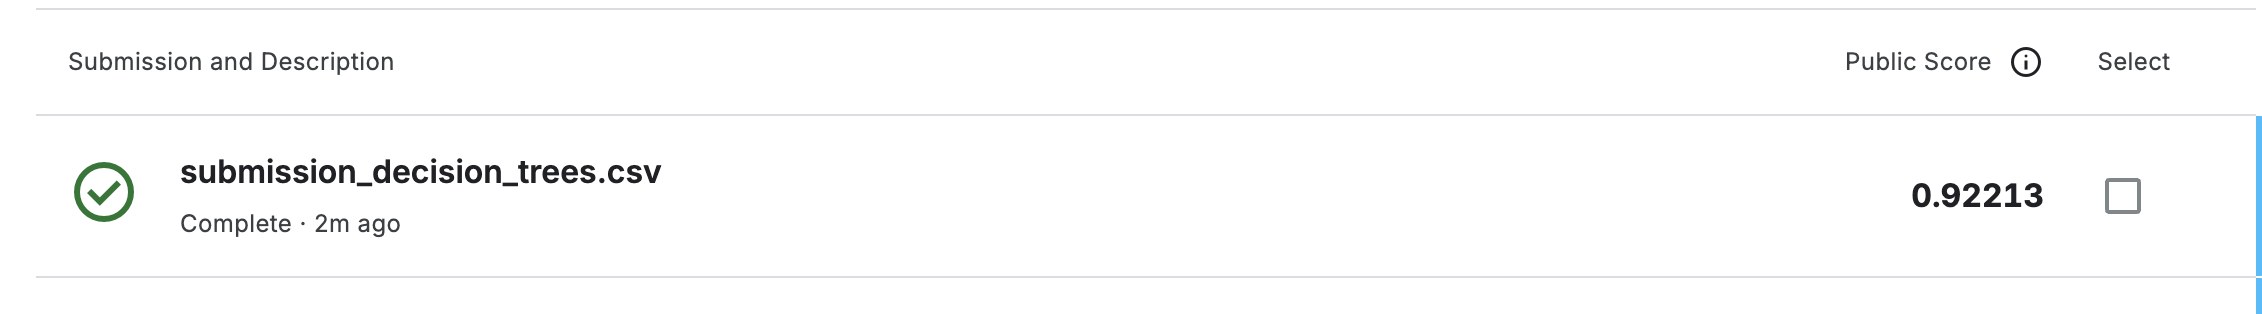